In [1]:
print("ANtas")


ANtas


In [2]:
## WITHOUT AUGUMENTATION

# --- ABC OPTIMIZATION ---

from sklearn.preprocessing import LabelEncoder
import joblib

#Data Setup
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# Load the original CLEANED text dataset (Not the encoded train.csv)
df_tab = pd.read_csv('/content/dataset.csv')

df_tab.columns = df_tab.columns.str.strip()

# Identify categorical columns (object dtype)
categorical_cols = df_tab.select_dtypes(include=['object']).columns.tolist()

encoders = {}
vocab_sizes = []

for col in categorical_cols:
    le = LabelEncoder()
    df_tab[col] = le.fit_transform(df_tab[col].astype(str))  # convert to string first
    encoders[col] = le
    vocab_sizes.append(len(le.classes_))

# Save encoders for later inference
joblib.dump(encoders, 'tab_encoders.pkl')

print("Categorical columns encoded successfully!")
print("Vocabulary sizes:", vocab_sizes)
print(df_tab[categorical_cols].head())
# Fix the rare anomaly in the Gravida column
df_tab['Gravida'] = df_tab['Gravida'].replace({'Multigravida+D1191': 'Multigravida'})

# Define which columns are numbers and which are text (Categories)
target = 'Labelling'
numerical_cols = ['Age', 'Gestational Age', 'Number of sons', 'Number of daughters',
                  'Total Number of Children', 'Scalling']

# Every other column except numericals and target is a categorical column
categorical_cols = [col for col in df_tab.columns if col not in numerical_cols and col != target]

print(f"Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")
print("\nABC Optimization Complete! No rare anomalies remain.")

# BLOCK 2: TabTransformer Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib

# 1. Scale the Numerical Columns
scaler = StandardScaler()
df_tab[numerical_cols] = scaler.fit_transform(df_tab[numerical_cols])
joblib.dump(scaler, 'tab_scaler.pkl')

# 2. Label Encode the Categorical Columns
# We also need to save the "vocabulary size" (how many unique categories exist in each column)
# because the Multi-Head Attention layers need to know exactly how many "embeddings" to build.
vocab_sizes = []
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_tab[col] = le.fit_transform(df_tab[col].astype(str))
    vocab_sizes.append(len(le.classes_))
    encoders[col] = le

joblib.dump(encoders, 'tab_encoders.pkl')

# 3. Train/Test Split (80/20)
X = df_tab.drop(target, axis=1)
y = df_tab[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Data scaled, encoded, and split perfectly for the TabTransformer!")
print(f"Vocabulary sizes for Attention Layers: {vocab_sizes}")

# Formatting Data for TabTransformer
import tensorflow as tf

# Keras functional API requires inputs as a dictionary or list
def prepare_transformer_inputs(X, cat_cols, num_cols):
    # Dictionary for categorical columns
    inputs = {col: X[col].values for col in cat_cols}
    # Single array for numerical columns
    inputs['numeric_input'] = X[num_cols].values
    return inputs

X_train_tf = prepare_transformer_inputs(X_train, categorical_cols, numerical_cols)
X_test_tf = prepare_transformer_inputs(X_test, categorical_cols, numerical_cols)

print("Data successfully formatted into Keras tensor inputs!")

# BLOCK 4 (UPGRADED): High-Capacity TabTransformer
from tensorflow.keras.layers import Input, Embedding, Concatenate, Dense, Flatten, MultiHeadAttention, LayerNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("--- Initializing High-Capacity TabTransformer ---")

# 1. Define Inputs & Thicker Embeddings
cat_inputs = []
cat_embeddings = []
embed_dim = 32 # UPGRADED: Doubled the mathematical vectors

for i, col in enumerate(categorical_cols):
    inp = Input(shape=(1,), name=col)
    cat_inputs.append(inp)

    vocab_size = vocab_sizes[i]
    emb = Embedding(input_dim=vocab_size, output_dim=embed_dim)(inp)
    cat_embeddings.append(emb)

numeric_input = Input(shape=(len(numerical_cols),), name='numeric_input')

# 2. Upgraded Transformer Block
x_cat = Concatenate(axis=1)(cat_embeddings)

# UPGRADED: 8 Attention Heads instead of 4
attention_out = MultiHeadAttention(num_heads=8, key_dim=embed_dim)(x_cat, x_cat)
x_cat = LayerNormalization()(x_cat + attention_out)
x_cat = Flatten()(x_cat)

x = Concatenate()([x_cat, numeric_input])

# 3. Deeper MLP Head
x = Dense(128, activation='relu')(x) # UPGRADED: Thicker dense layer
x = Dropout(0.2)(x) # Reduced dropout slightly to allow more data flow
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

tab_model = Model(inputs=cat_inputs + [numeric_input], outputs=output)

# Slower, more careful initial learning rate
optimizer = Adam(learning_rate=0.001)
tab_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# 4. Dynamic Learning Rate & Patient Early Stopping
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)

# Wait 20 epochs before giving up completely
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

print("Training started...")
history = tab_model.fit(
    X_train_tf, y_train,
    validation_split=0.2,
    epochs=100, # Increased max epochs
    batch_size=32, # UPGRADED: Smaller batch size for better generalization
    callbacks=[early_stop, lr_scheduler],
    verbose=0
)

# 5. Evaluate
tab_probs = tab_model.predict(X_test_tf)
tab_preds = (tab_probs > 0.5).astype(int).flatten()

tab_acc = accuracy_score(y_test, tab_preds)

tab_model.save('tabtransformer_optimized.h5')



Categorical columns encoded successfully!
Vocabulary sizes: [3, 8, 8, 3, 2, 4, 5, 5, 2, 5, 3, 2]
   Gravida  Female Education  Husband Education  Working Status  \
0        2                 0                  0               0   
1        0                 1                  2               2   
2        2                 0                  0               0   
3        0                 0                  0               0   
4        2                 0                  0               0   

   Physical Health  Previous Miscarriage  Sufficient Money for Basic Needs  \
0                1                     0                                 2   
1                1                     0                                 2   
2                1                     0                                 2   
3                1                     0                                 2   
4                1                     0                                 2   

   Current Appereance Acceptanc

In [10]:
import pandas as pd
import joblib
import tensorflow as tf

# 1. Load test.csv
test_df = pd.read_csv("test.csv")

# 2. Clean column names (strip spaces if any)
test_df.columns = test_df.columns.str.strip()

# 3. Load saved preprocessing objects
scaler = joblib.load("tab_scaler.pkl")
encoders = joblib.load("tab_encoders.pkl")

numerical_cols = ['Age', 'Gestational Age', 'Number of sons',
                  'Number of daughters', 'Total Number of Children', 'Scalling']

categorical_cols = [col for col in test_df.columns if col not in numerical_cols and col != 'Labelling']

# 4. Apply scaling to numerical columns
test_df[numerical_cols] = scaler.transform(test_df[numerical_cols])

# 5. Apply label encoding to categorical columns
for col in categorical_cols:
    le = encoders[col]
    # Handle unseen categories by mapping them to -1 or a default
    test_df[col] = test_df[col].astype(str).map(lambda x: le.transform([x])[0] if x in le.classes_ else -1)

# 6. Prepare inputs for TabTransformer
def prepare_transformer_inputs(X, cat_cols, num_cols):
    inputs = {}
    for col in cat_cols:
        inputs[col] = X[col].astype('int32').values
    inputs['numeric_input'] = X[num_cols].astype('float32').values
    return inputs

X_test_tf = prepare_transformer_inputs(test_df, categorical_cols, numerical_cols)

# 8. Predict
tab_probs = tab_model.predict(X_test_tf)
tab_preds = (tab_probs< 0.5).astype(int).flatten()


from sklearn.metrics import classification_report
print(classification_report(test_df['Labelling'], tab_preds))

188/188 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

              precision    recall  f1-score   support

           0       0.67      0.87      0.75      2140
           1       0.91      0.76      0.83      3860

    accuracy                           0.80      6000
   macro avg       0.79      0.81      0.79      6000
weighted avg       0.82      0.80      0.80      6000



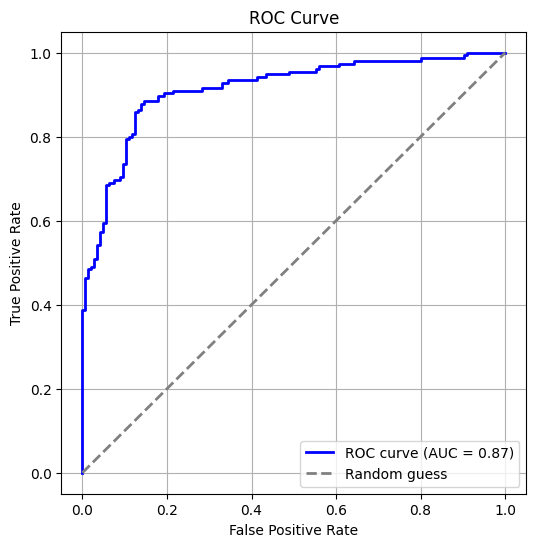

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 5. Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, tab_preds)
roc_auc = auc(fpr, tpr)

# 6. Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--",
         label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [18]:
# -*- coding: utf-8 -*-
"""Tab_transformer_PPD.ipynb

Automatically generated by Colab.

"""

print("Antas")

# Data Setup
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, roc_auc_score # Added roc_auc_score

# Load the original CLEANED text dataset
df_tab = pd.read_csv('30k_ppd_CTGAN_cleaned.csv')

# Define which columns are numbers and which are text (Categories)
target = 'Labelling'
numerical_cols = ['Age', 'Gestational Age', 'Number of sons', 'Number of daughters',
                  'Total Number of Children', 'Scalling']

# Every other column except numericals and target is a categorical column
categorical_cols = [col for col in df_tab.columns if col not in numerical_cols and col != target]

print(f"Numerical Columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical Columns ({len(categorical_cols)}): {categorical_cols}")
print("\nData loaded. ABC Optimization removed.")

# BLOCK 2: TabTransformer Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib

# 1. Scale the Numerical Columns
scaler = StandardScaler()
df_tab[numerical_cols] = scaler.fit_transform(df_tab[numerical_cols])
joblib.dump(scaler, 'tab_scaler.pkl')

# 2. Label Encode the Categorical Columns
vocab_sizes = []
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df_tab[col] = le.fit_transform(df_tab[col].astype(str))
    vocab_sizes.append(len(le.classes_))
    encoders[col] = le

joblib.dump(encoders, 'tab_encoders.pkl')

# 3. Train/Test Split (80/20)
X = df_tab.drop(target, axis=1)
y = df_tab[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

print("Data scaled, encoded, and split perfectly for the TabTransformer!")
print(f"Vocabulary sizes for Attention Layers: {vocab_sizes}")

# BLOCK 3: Formatting Data for TabTransformer
import tensorflow as tf

# Keras functional API requires inputs as a dictionary or list
def prepare_transformer_inputs(X, cat_cols, num_cols):
    # Dictionary for categorical columns
    inputs = {col: X[col].values for col in cat_cols}
    # Single array for numerical columns
    inputs['numeric_input'] = X[num_cols].values
    return inputs

X_train_tf = prepare_transformer_inputs(X_train, categorical_cols, numerical_cols)
X_test_tf = prepare_transformer_inputs(X_test, categorical_cols, numerical_cols)

print("Data successfully formatted into Keras tensor inputs!")

# BLOCK 4 (UPGRADED): High-Capacity TabTransformer
from tensorflow.keras.layers import Input, Embedding, Concatenate, Dense, Flatten, MultiHeadAttention, LayerNormalization, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("--- Initializing High-Capacity TabTransformer ---")

# 1. Define Inputs & Thicker Embeddings
cat_inputs = []
cat_embeddings = []
embed_dim = 32

for i, col in enumerate(categorical_cols):
    inp = Input(shape=(1,), name=col)
    cat_inputs.append(inp)

    vocab_size = vocab_sizes[i]
    emb = Embedding(input_dim=vocab_size, output_dim=embed_dim)(inp)
    cat_embeddings.append(emb)

numeric_input = Input(shape=(len(numerical_cols),), name='numeric_input')

# 2. Upgraded Transformer Block
x_cat = Concatenate(axis=1)(cat_embeddings)

attention_out = MultiHeadAttention(num_heads=8, key_dim=embed_dim)(x_cat, x_cat)
x_cat = LayerNormalization()(x_cat + attention_out)
x_cat = Flatten()(x_cat)

x = Concatenate()([x_cat, numeric_input])

# 3. Deeper MLP Head
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

tab_model = Model(inputs=cat_inputs + [numeric_input], outputs=output)

# Slower, more careful initial learning rate
optimizer = Adam(learning_rate=0.001)
tab_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# 4. Dynamic Learning Rate & Patient Early Stopping
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)

# Wait 20 epochs before giving up completely
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

print("Training started...")
history = tab_model.fit(
    X_train_tf, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=0
)

# 5. Evaluate
tab_probs = tab_model.predict(X_test_tf)
tab_preds = (tab_probs > 0.5).astype(int).flatten()

tab_acc = accuracy_score(y_test, tab_preds)
tab_roc_auc = roc_auc_score(y_test, tab_probs) # Calculates the exact ROC AUC

tab_model.save('tabtransformer_optimized.h5')

print("\n=== FINAL MODEL EVALUATION ===")
print(f"Accuracy:  {tab_acc:.4f}")
print(f"ROC AUC:   {tab_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, tab_preds))

Antas
Numerical Columns (6): ['Age', 'Gestational Age', 'Number of sons', 'Number of daughters', 'Total Number of Children', 'Scalling']
Categorical Columns (20): ['Gravida', 'Female Education', 'Husband Education', 'Working Status', 'Physical Health', 'Previous Miscarriage', 'Sufficient Money for Basic Needs', 'Current Appereance Acceptance', 'Family System', 'Male Gender Preference', 'Relationship with Mother in-law', 'Little interest or pleasure in doing things', 'Feeling down, depressed, or hopeless', 'Trouble falling or staying sleep or sleeping too much', 'Feeling tired or having little energy', 'Poor appetite or overeating', 'Feeling badabout yourself that you are failure or have let yourself or your family down', 'Trouble concentrating on things, such as reading the newspaper or watching television', 'Moving or speaking so slowly that other people could have Noticed.', 'Thoughts that you would be better off dead, or of hurting yourself']

Data loaded. ABC Optimization removed.



=== FINAL MODEL EVALUATION ===
Accuracy:  0.9412
ROC AUC:   0.9737

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.92      2140
           1       0.95      0.96      0.95      3860

    accuracy                           0.94      6000
   macro avg       0.94      0.93      0.94      6000
weighted avg       0.94      0.94      0.94      6000



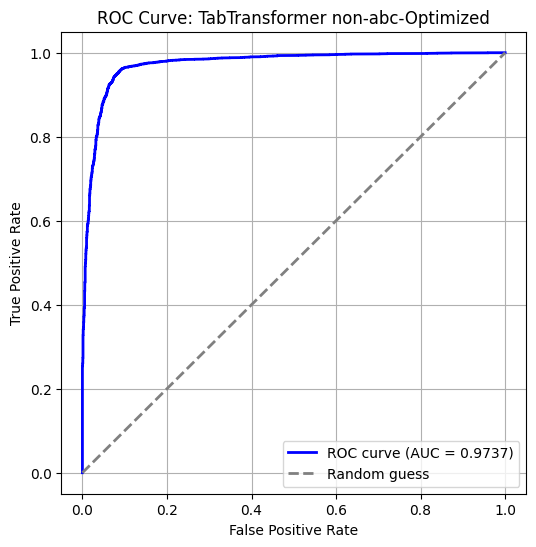

In [19]:
# === ROC Curve Plot ===
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, tab_probs)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2,
         label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--",
         label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: TabTransformer non-abc-Optimized")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [14]:
# -*- coding: utf-8 -*-
"""Ablation_Study_No_Attention_Fixed.ipynb"""

import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, Concatenate, Dense, Flatten, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

print("--- 1. Data Setup & Preprocessing ---")
# Load the original dataset
df_tab = pd.read_csv('30k_ppd_CTGAN_cleaned.csv')

# --- THE FIX: DROP MISSING VALUES ---
initial_len = len(df_tab)
df_tab = df_tab.dropna()
print(f"Dropped {initial_len - len(df_tab)} rows with missing values (NaNs).")

# Define which columns are numbers and which are text (Categories)
target = 'Labelling'
numerical_cols = ['Age', 'Gestational Age', 'Number of sons', 'Number of daughters',
                  'Total Number of Children', 'Scalling']

# Every other column except numericals and target is a categorical column
categorical_cols = [col for col in df_tab.columns if col not in numerical_cols and col != target]

# Scale the Numerical Columns
scaler = StandardScaler()
df_tab[numerical_cols] = scaler.fit_transform(df_tab[numerical_cols])

# Label Encode the Categorical Columns
vocab_sizes = []
for col in categorical_cols:
    le = LabelEncoder()
    df_tab[col] = le.fit_transform(df_tab[col].astype(str))
    vocab_sizes.append(len(le.classes_))

# Train/Test Split (80/20)
X = df_tab.drop(target, axis=1)
y = df_tab[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# Formatting Data for Keras
def prepare_transformer_inputs(X_df, cat_cols, num_cols):
    inputs = {col: X_df[col].values for col in cat_cols}
    inputs['numeric_input'] = X_df[num_cols].values
    return inputs

X_train_tf = prepare_transformer_inputs(X_train, categorical_cols, numerical_cols)
X_test_tf = prepare_transformer_inputs(X_test, categorical_cols, numerical_cols)

print("Data scaled, encoded, and formatted successfully!")

print("\n--- 2. Initializing Ablation Model (WITHOUT Attention Mechanism) ---")
# Define Inputs & Embeddings
cat_inputs = []
cat_embeddings = []
embed_dim = 32

for i, col in enumerate(categorical_cols):
    inp = Input(shape=(1,), name=col)
    cat_inputs.append(inp)
    emb = Embedding(input_dim=vocab_sizes[i], output_dim=embed_dim)(inp)
    cat_embeddings.append(emb)

numeric_input = Input(shape=(len(numerical_cols),), name='numeric_input')

# ABLATION CHANGE: No MultiHeadAttention or LayerNormalization.
# Just combine and flatten the embeddings directly.
x_cat = Concatenate(axis=1)(cat_embeddings)
x_cat = Flatten()(x_cat)

# Combine the flattened categorical embeddings with the numerical inputs
x = Concatenate()([x_cat, numeric_input])

# Deeper MLP Head (Kept identical to the full model for a fair comparison)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(32, activation='relu')(x)
output = Dense(1, activation='sigmoid')(x)

ablation_model = Model(inputs=cat_inputs + [numeric_input], outputs=output)

# Compile
optimizer = Adam(learning_rate=0.001)
ablation_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.00001, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

print("\n--- 3. Training started (No Attention)... ---")
history = ablation_model.fit(
    X_train_tf, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=0
)

print("\n--- 4. Evaluation & Results ---")
ablation_probs = ablation_model.predict(X_test_tf, verbose=0)
ablation_preds = (ablation_probs > 0.5).astype(int).flatten()

# Calculate specific metrics for the Ablation Table
acc = accuracy_score(y_test, ablation_preds)
prec = precision_score(y_test, ablation_preds)
rec = recall_score(y_test, ablation_preds)
f1 = f1_score(y_test, ablation_preds)
roc_auc = roc_auc_score(y_test, ablation_probs)

print("\n===========================================")
print("  ABLATION RESULTS: WITHOUT ATTENTION")
print("===========================================")
print(f"Accuracy:   {acc:.4f}")
print(f"Precision:  {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1-Score:   {f1:.4f}")
print(f"ROC AUC:    {roc_auc:.4f}")
print("===========================================")

--- 1. Data Setup & Preprocessing ---
Dropped 212 rows with missing values (NaNs).
Data scaled, encoded, and formatted successfully!

--- 2. Initializing Ablation Model (WITHOUT Attention Mechanism) ---

--- 3. Training started (No Attention)... ---

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.

Epoch 17: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.

Epoch 22: ReduceLROnPlateau reducing learning rate to 1e-05.

--- 4. Evaluation & Results ---

  ABLATION RESULTS: WITHOUT ATTENTION
Accuracy:   0.9466
Precision:  0.9496
Recall:     0.9684
F1-Score:   0.9589
ROC AUC:    0.9801


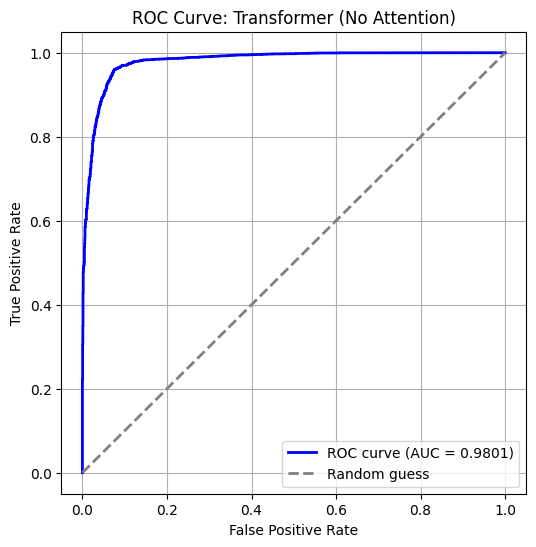

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, ablation_probs)
roc_auc_val = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color="blue", lw=2,
         label=f"ROC curve (AUC = {roc_auc_val:.4f})")
plt.plot([0, 1], [0, 1], color="gray", lw=2, linestyle="--",
         label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Transformer (No Attention)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()
